In [13]:
from fiat_toolbox.well_being import (
    CapitalStock,
    CommunityUnit,
    IncomeConfig,
    Liquidity,
    SimulationConfig,
    WellBeingConfig,
)

In [14]:
housing_assets = CapitalStock(v=0.7, k=120000, pi=0.15)
rental_assets = CapitalStock(v=0.7, k=80000, recovery_time=10, pi=0.15)

public_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=10, pi=0.15)
private_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=4, pi=0.15)

# Baseline c0 = Σ π·k + i_div = 0.15*(120000+80000+50000+50000) + 20000 = 65000.
# i_div captures income not tied to any modelled stock (transfers, etc.).
income_config = IncomeConfig(i_avg=48000, i_div=20000)

sim_config = SimulationConfig(
    eta=1.5, rho=0.06, t_max=10, dt=1 / 52, currency="$", c_min=5000, recovery_per=95.0
)

liq = Liquidity(savings=200000)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public": public_assets, "Private": private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq,
)

In [15]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=120000.0 v=0.7 recovery_time=None recovery_rate=None pi=0.15 recovery_label=None income_label=None,
  rental_housing = k=80000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399 pi=0.15 recovery_label=None income_label=None,
  labour_assets = {'Public': CapitalStock(k=50000.0, v=0.4, recovery_time=10.0, recovery_rate=0.299573227355399, pi=0.15, recovery_label=None, income_label=None), 'Private': CapitalStock(k=50000.0, v=0.4, recovery_time=4.0, recovery_rate=0.7489330683884975, pi=0.15, recovery_label=None, income_label=None)},
  income = i_0=None i_avg=48000.0 i_div=20000.0,
  liquidity = savings=200000.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=5000.0 recovery_per=95.0
)

Status: flat
Success: True
Message: Welfare function is flat across λ ∈ [0.3, 9.99] (loss range 0.000e+00, within eps_flat=0.001 of loss scale). Every λ gives essentially the same welfare loss; returned λ=9.99 is the coarse-grid argmin (ties toward fastest recovery — consistent with the eps_rel convention). The household is effectively indifferent to reconstruction speed in this regime (e.g. zero damage, or liquidity covers all losses).


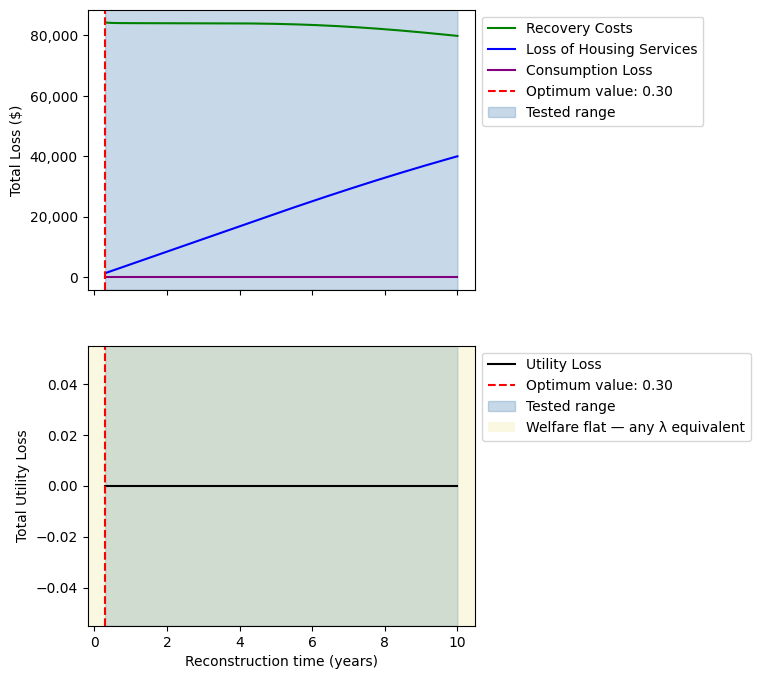

In [16]:
res = household.opt_lambda(raise_on_fail=False)
# opt_lambda classifies its outcome via `res["status"]` (OptLambdaStatus):
# INTERIOR / FLAT / BOUNDARY_LOWER / BOUNDARY_UPPER / INFEASIBLE / FAILED.
# `res["message"]` carries a short explanation and an actionable hint
# whenever the result is non-trivial. For this config the optimum lands at
# the slowest end of the λ search range (BOUNDARY_LOWER) — the plot
# annotates the boundary with a red marker.
print(f"Status: {res['status']}")
print(f"Success: {res['success']}")
if res["message"]:
    print(f"Message: {res['message']}")
if res["success"]:
    household.plot_opt_lambda(x_type="time")

In [17]:
household.get_losses("trapezoid")

Recovery Costs                       84256.992429
Loss of Housing Services              1265.655377
Loss of Housing Services (Rental)    26637.967808
Labour Income Loss (Public)           9513.559931
Labour Income Loss (Private)          4003.528094
Labour Income Loss                   13517.088025
Consumption Loss                         0.000000
Utility Loss                             0.000000
Wellbeing Loss                       80796.771074
Wellbeing Loss (Integral)                0.000000
Wellbeing Loss (Liquidity Term)      80796.771074
Asset Loss                           84000.000000
Equity Weighted Asset Loss           53305.387793
Socio-economic Resilience                1.039646
dtype: float64

In [18]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
print(
    f"Achieved recovery in {household.config.simulation.t_max} years: {household.achieved_recovery_percent():.2f} %"
)

Recovery Time: 0.30 years
Achieved recovery in 10.0 years: 97.88 %


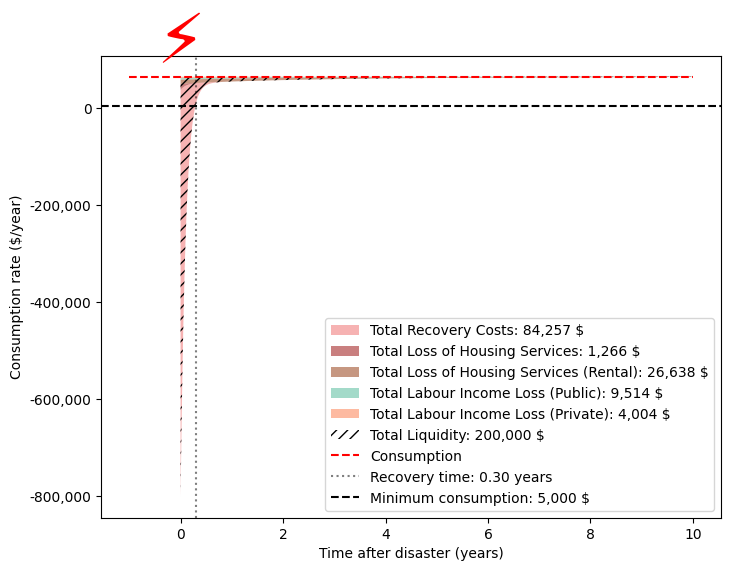

In [19]:
household.plot_consumption()

## Sensitivity analysis

So far we looked at one configuration. Recovery dynamics depend on many knobs — damage severity, liquidity, diversified income, … — so let's sweep them and see how the **recovery times** change:

- **household τ** (`hh.recovery_time`) — the owner's reconstruction horizon (paper §2.3.5 formula, uses the owner's optimised rate alone).
- **composite τ** (`hh.composite_recovery_time()`) — the aggregate horizon across owner + rental + labour capital; slower components pull this up.
- **achieved recovery %** by `t_max` — how much of the asset stock has been rebuilt when the simulation ends.

The helper below builds a unit with a given (damage, diversified income, savings) triple and returns those metrics. Infeasible configurations return `NaN`s so the downstream plots show gaps instead of crashing.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def sensitivity_run(v=0.7, i_div=20000, savings=0):
    """Build a CommunityUnit with the given knobs, optimise, and return
    recovery-time metrics. Rental / labour structure stays fixed at the
    notebook's baseline values; only owner damage (v), diversified
    income (i_div), and savings vary.

    Returns a dict with NaN values when the configuration is
    infeasible (no feasible λ in the search range).
    """
    cfg = WellBeingConfig(
        owner_housing=CapitalStock(v=v, k=120000, pi=0.15),
        rental_housing=CapitalStock(v=0.7, k=80000, recovery_time=10, pi=0.15),
        labour_assets={
            "Public": CapitalStock(v=0.4, k=50000, recovery_time=10, pi=0.15),
            "Private": CapitalStock(v=0.4, k=50000, recovery_time=4, pi=0.15),
        },
        income=IncomeConfig(i_avg=48000, i_div=i_div),
        simulation=SimulationConfig(
            eta=1.5,
            rho=0.06,
            t_max=10,
            dt=1 / 52,
            currency="$",
            c_min=5000,
            recovery_per=95.0,
        ),
        liquidity=Liquidity(savings=savings),
    )
    hh = CommunityUnit(cfg)
    opt = hh.opt_lambda(raise_on_fail=False)
    if not opt["success"]:
        return {
            "household_tau": np.nan,
            "composite_tau": np.nan,
            "achieved_tmax": np.nan,
            "wellbeing_loss": np.nan,
            "per_component": None,
            "status": str(opt["status"]),
        }
    hh.get_losses("trapezoid")
    return {
        "household_tau": float(hh.recovery_time),
        "composite_tau": float(hh.composite_recovery_time() or np.nan),
        "achieved_tmax": float(hh.achieved_recovery_percent() or np.nan),
        "wellbeing_loss": float(hh.total_losses["Wellbeing Loss"]),
        "per_component": hh.recovery_time_per_component,
        "status": str(opt["status"]),
    }

### Effect of damage on recovery time

Varying the damage ratio `v` on owner housing (rental and labour held fixed). As `v` grows, the reconstruction burden grows too; at some point the feasibility constraint `c(t) ≥ c_min` bites and the optimiser can no longer find a viable λ — those rows return `NaN`.

,v,household_τ,composite_τ,achieved %,status
0,0.1,10.0,9.327833,95.915574,boundary_lower
1,0.2,10.0,9.401150,95.824016,boundary_lower
2,0.3,10.0,9.460027,95.749106,boundary_lower
3,0.4,10.0,9.508350,95.686680,boundary_lower
4,0.5,10.0,9.548727,95.633859,boundary_lower
5,0.6,10.0,9.582970,95.588583,boundary_lower
6,0.7,10.0,9.612379,95.549344,boundary_lower
7,0.8,10.0,9.637911,95.515010,boundary_lower
8,0.9,NaN,NaN,NaN,infeasible


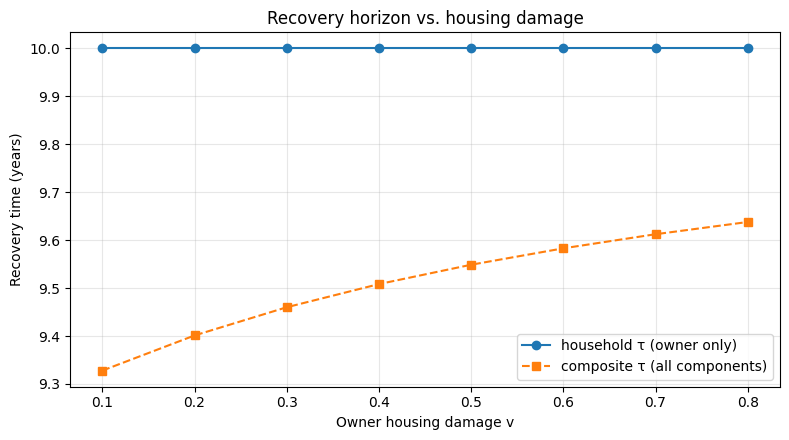

In [9]:
v_grid = np.round(np.linspace(0.1, 0.9, 9), 2)
rows = []
for v in v_grid:
    m = sensitivity_run(v=float(v))
    rows.append(
        {
            "v": v,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "achieved %": m["achieved_tmax"],
            "status": m["status"],
        }
    )
df_v = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_v["v"], df_v["household_τ"], marker="o", label="household τ (owner only)")
ax.plot(
    df_v["v"],
    df_v["composite_τ"],
    marker="s",
    linestyle="--",
    label="composite τ (all components)",
)
ax.set_xlabel("Owner housing damage v")
ax.set_ylabel("Recovery time (years)")
ax.set_title("Recovery horizon vs. housing damage")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
df_v

### Effect of liquidity on recovery

Savings, insurance, and external support smooth consumption through the recovery period. More liquidity → the household can tolerate higher reconstruction peaks → household τ tends to drop (faster recovery becomes feasible) and welfare loss shrinks.

,savings,household_τ,composite_τ,wellbeing_loss,status
0,0,10.000000,9.612379,147365.423784,boundary_lower
1,5000,10.000000,9.612379,133087.195428,boundary_lower
2,15000,10.000000,9.612379,119518.136056,boundary_lower
3,30000,10.000000,9.612379,108510.304211,boundary_lower
4,60000,2.462012,7.161921,92221.506230,interior
5,100000,0.300000,7.156881,77130.123638,boundary_upper
6,200000,0.300000,7.156881,80796.771074,flat


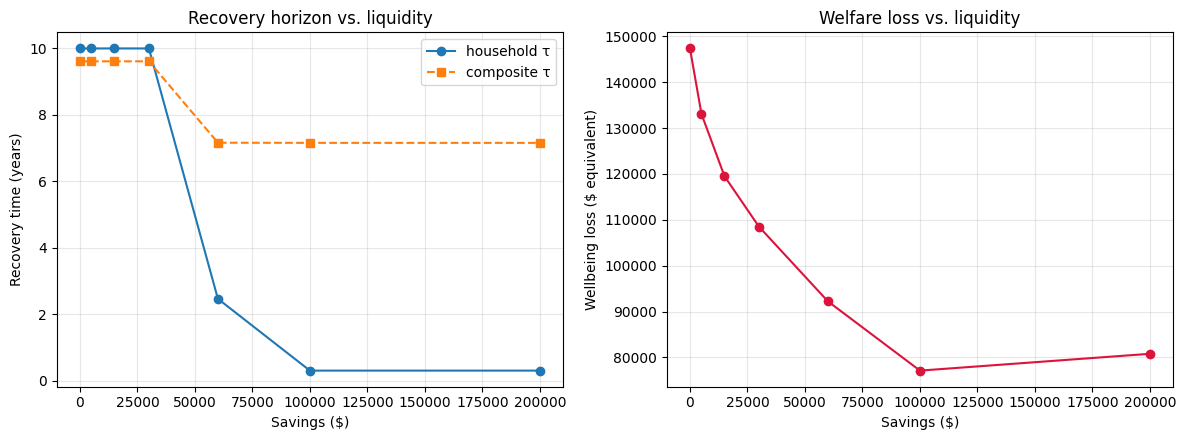

In [10]:
savings_grid = [0, 5_000, 15_000, 30_000, 60_000, 100_000, 200_000]
rows = []
for s in savings_grid:
    m = sensitivity_run(savings=float(s))
    rows.append(
        {
            "savings": s,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "wellbeing_loss": m["wellbeing_loss"],
            "status": m["status"],
        }
    )
df_s = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(df_s["savings"], df_s["household_τ"], marker="o", label="household τ")
ax1.plot(
    df_s["savings"],
    df_s["composite_τ"],
    marker="s",
    linestyle="--",
    label="composite τ",
)
ax1.set_xlabel("Savings ($)")
ax1.set_ylabel("Recovery time (years)")
ax1.set_title("Recovery horizon vs. liquidity")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(df_s["savings"], df_s["wellbeing_loss"], marker="o", color="crimson")
ax2.set_xlabel("Savings ($)")
ax2.set_ylabel("Wellbeing loss ($ equivalent)")
ax2.set_title("Welfare loss vs. liquidity")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
df_s

### Effect of diversified income

`i_div` represents non-asset-based residual income (remittances, transfers, pensions). It raises the baseline `c0 = Σ π·k + i_div`, giving the household more headroom to absorb the peak consumption drop at `t=0` — so more aggressive recovery rates become feasible.

,i_div,household_τ,composite_τ,wellbeing_loss,status
0,5000,NaN,NaN,NaN,infeasible
1,10000,NaN,NaN,NaN,infeasible
2,20000,10.0,9.612379,147365.423784,boundary_lower
3,40000,10.0,9.612379,81782.759025,boundary_lower
4,80000,10.0,9.612379,40010.196535,boundary_lower


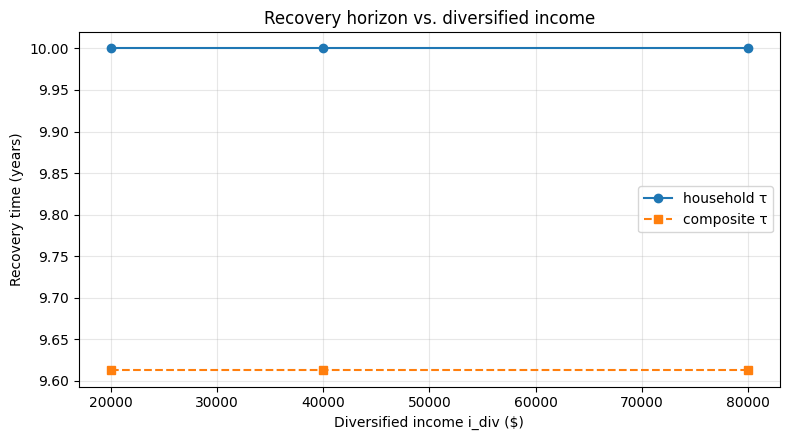

In [11]:
i_div_grid = [5_000, 10_000, 20_000, 40_000, 80_000]
rows = []
for i in i_div_grid:
    m = sensitivity_run(i_div=float(i))
    rows.append(
        {
            "i_div": i,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "wellbeing_loss": m["wellbeing_loss"],
            "status": m["status"],
        }
    )
df_i = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_i["i_div"], df_i["household_τ"], marker="o", label="household τ")
ax.plot(
    df_i["i_div"], df_i["composite_τ"], marker="s", linestyle="--", label="composite τ"
)
ax.set_xlabel("Diversified income i_div ($)")
ax.set_ylabel("Recovery time (years)")
ax.set_title("Recovery horizon vs. diversified income")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
df_i

### Joint damage × liquidity heatmap

A 2-D grid shows how the two knobs interact. The left panel is the household-only τ (owner reconstruction horizon); the right panel is the composite τ across owner + rental + labour. Blank cells are infeasible configurations where no λ in the default search range keeps `c(t) ≥ c_min`.

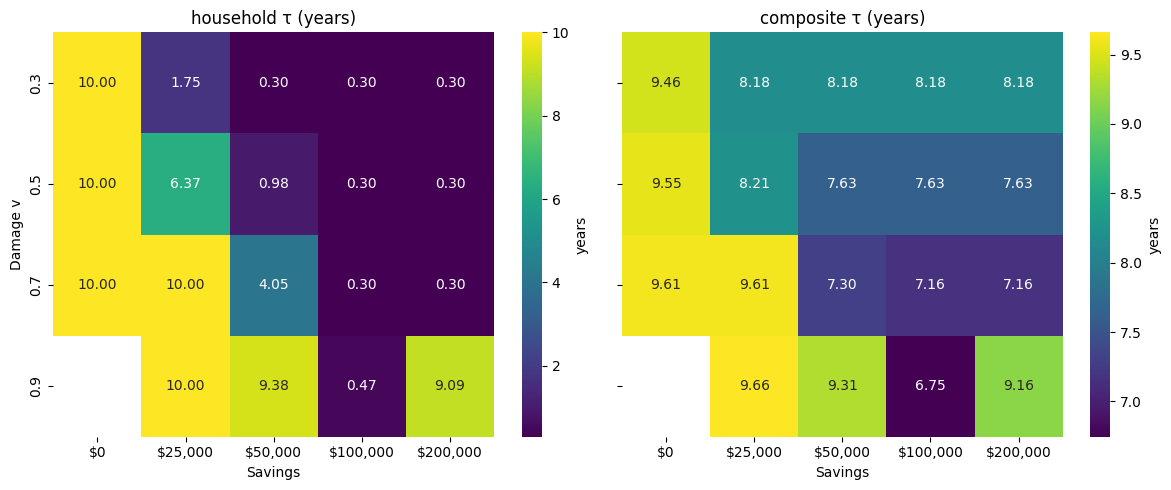

In [12]:
v_axis = [0.3, 0.5, 0.7, 0.9]
s_axis = [0, 25_000, 50_000, 100_000, 200_000]

hh_mat = np.full((len(v_axis), len(s_axis)), np.nan)
co_mat = np.full((len(v_axis), len(s_axis)), np.nan)
for i, v in enumerate(v_axis):
    for j, s in enumerate(s_axis):
        m = sensitivity_run(v=float(v), savings=float(s))
        hh_mat[i, j] = m["household_tau"]
        co_mat[i, j] = m["composite_tau"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, data, title in [
    (ax1, hh_mat, "household τ (years)"),
    (ax2, co_mat, "composite τ (years)"),
]:
    sns.heatmap(
        data,
        xticklabels=[f"${s:,.0f}" for s in s_axis],
        yticklabels=[f"{v:.1f}" for v in v_axis],
        annot=True,
        fmt=".2f",
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": "years"},
    )
    ax.set_xlabel("Savings")
    ax.set_title(title)
ax1.set_ylabel("Damage v")
plt.tight_layout()